In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    silhouette_score,
    confusion_matrix,
    classification_report
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [2]:
from google.colab import files

uploaded = files.upload()

Saving adult_cleaned.csv to adult_cleaned.csv


In [4]:
df = pd.read_csv("adult_cleaned.csv")

print("Dataset shape:", df.shape)
df.head()

print("Missing values:")
print(df.isnull().sum().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nDataset shape:")
print(df.shape)

Dataset shape: (32537, 15)
Missing values:
0

Duplicate rows:
0

Dataset shape:
(32537, 15)


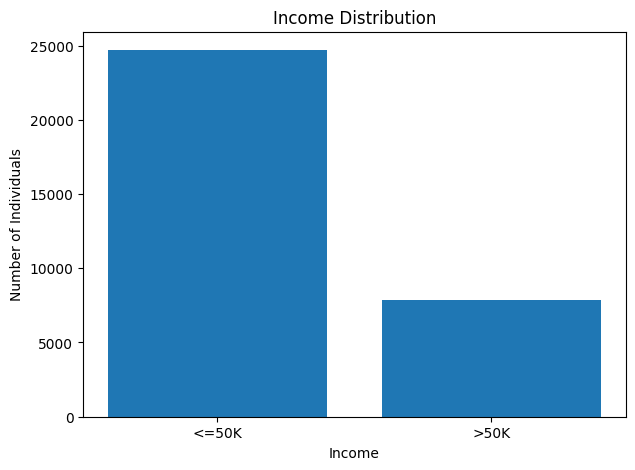

In [5]:
income_counts = df["income"].value_counts()

plt.figure(figsize=(7,5))
plt.bar(income_counts.index, income_counts.values)

plt.title("Income Distribution")
plt.xlabel("Income")
plt.ylabel("Number of Individuals")

plt.show()

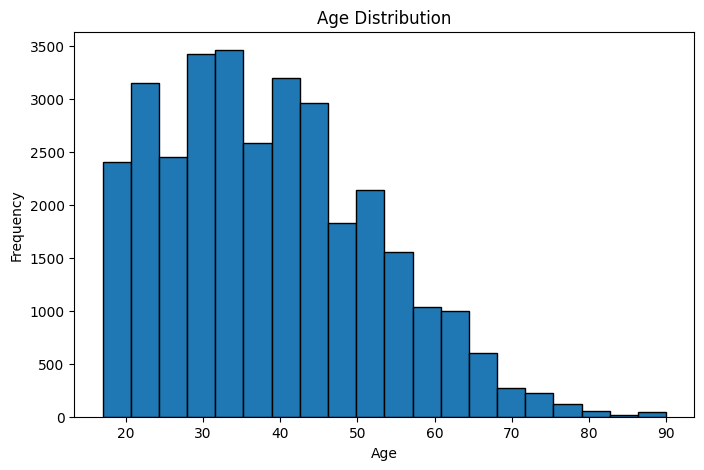

In [6]:
plt.figure(figsize=(8,5))

plt.hist(df["age"], bins=20, edgecolor="black")

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

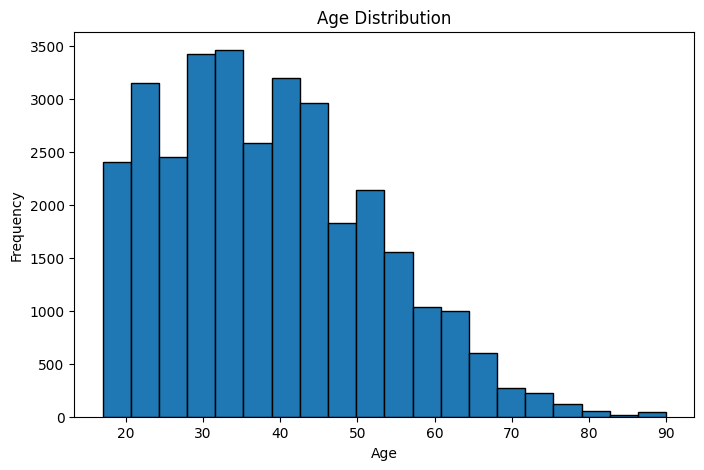

In [7]:
plt.figure(figsize=(8,5))

plt.hist(df["age"], bins=20, edgecolor="black")

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

In [8]:
features = [
    "age",
    "education_num",
    "capital_gain",
    "capital_loss",
    "hours_per_week"
]

X_cluster = df[features].copy()

In [9]:
cluster_scaler = StandardScaler()

X_cluster_scaled = cluster_scaler.fit_transform(
    X_cluster
)

In [10]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(
    X_cluster_scaled
)

df["cluster"] = clusters

print(df["cluster"].value_counts().sort_index())

cluster
0     1484
1    15475
2    15419
3      159
Name: count, dtype: int64


In [11]:
silhouette = silhouette_score(
    X_cluster_scaled,
    clusters
)

print("Silhouette Score:", round(silhouette, 4))

Silhouette Score: 0.2589


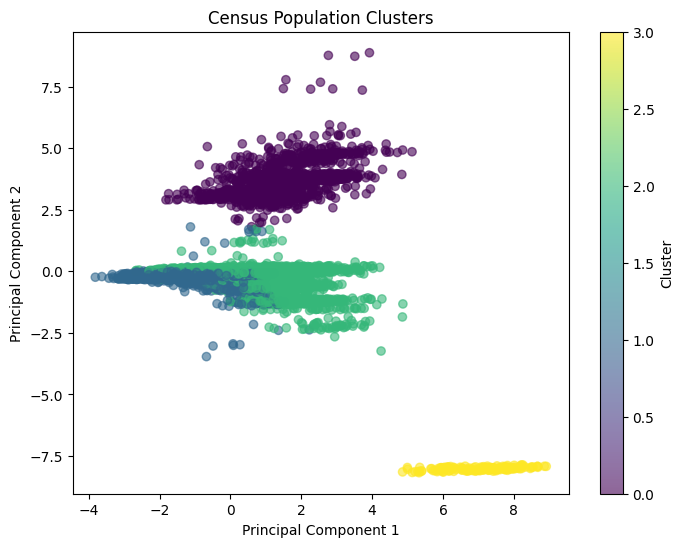

In [12]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(
    X_cluster_scaled
)

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters,
    alpha=0.6
)

plt.title("Census Population Clusters")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.colorbar(label="Cluster")

plt.show()

In [13]:
X = df.drop(
    ["income", "cluster"],
    axis=1
)

y = df["income"].map({
    "<=50K": 0,
    ">50K": 1
})

categorical_columns = X.select_dtypes(
    include="object"
).columns

X_encoded = pd.get_dummies(
    X,
    columns=categorical_columns,
    drop_first=True
)

print("Encoded shape:", X_encoded.shape)

Encoded shape: (32537, 100)


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [15]:
model_scaler = StandardScaler()

X_train_scaled = model_scaler.fit_transform(
    X_train
)

X_test_scaled = model_scaler.transform(
    X_test
)

In [18]:
log_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_model.fit(
    X_train_scaled,
    y_train
)

log_pred = log_model.predict(
    X_test_scaled
)

In [19]:
log_accuracy = accuracy_score(y_test, log_pred)
log_precision = precision_score(y_test, log_pred)
log_recall = recall_score(y_test, log_pred)
log_f1 = f1_score(y_test, log_pred)

print("Logistic Regression")
print("=" * 30)
print("Accuracy :", round(log_accuracy, 4))
print("Precision:", round(log_precision, 4))
print("Recall   :", round(log_recall, 4))
print("F1 Score :", round(log_f1, 4))

Logistic Regression
Accuracy : 0.8574
Precision: 0.7413
Recall   : 0.6269
F1 Score : 0.6793


In [20]:
nn_model = Sequential([
    Dense(
        64,
        activation="relu",
        input_shape=(X_train_scaled.shape[1],)
    ),

    Dropout(0.3),

    Dense(
        32,
        activation="relu"
    ),

    Dropout(0.2),

    Dense(
        1,
        activation="sigmoid"
    )
])

nn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

nn_model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         6,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,577 (33.50 KB)

 Trainable params: 8,577 (33.50 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
history = nn_model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    verbose=1
)

Epoch 1/20
651/651 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.8192 - loss: 0.3955 - val_accuracy: 0.8415 - val_loss: 0.3449
Epoch 2/20
651/651 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8410 - loss: 0.3420 - val_accuracy: 0.8429 - val_loss: 0.3363
Epoch 3/20
651/651 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8450 - loss: 0.3309 - val_accuracy: 0.8458 - val_loss: 0.3332
Epoch 4/20
651/651 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8473 - loss: 0.3235 - val_accuracy: 0.8427 - val_loss: 0.3318
Epoch 5/20
651/651 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8516 - loss: 0.3224 - val_accuracy: 0.8465 - val_loss: 0.3286
Epoch 6/20
651/651 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8524 - loss: 0.3139 - val_accuracy: 0.8492 - val_loss: 0.3283
Epoch 7/20
651/651 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8545 - loss: 0.3127 - val_accuracy: 0.8488 - val_loss: 0.3264
Epoch 8/20
651/651 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8587 - loss: 0.3074 - val_accuracy: 0.

In [22]:
nn_prob = nn_model.predict(
    X_test_scaled
)

nn_pred = (
    nn_prob >= 0.5
).astype(int).flatten()

204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [23]:
nn_accuracy = accuracy_score(y_test, nn_pred)
nn_precision = precision_score(y_test, nn_pred)
nn_recall = recall_score(y_test, nn_pred)
nn_f1 = f1_score(y_test, nn_pred)

print("Neural Network")
print("=" * 30)
print("Accuracy :", round(nn_accuracy, 4))
print("Precision:", round(nn_precision, 4))
print("Recall   :", round(nn_recall, 4))
print("F1 Score :", round(nn_f1, 4))

Neural Network
Accuracy : 0.8556
Precision: 0.7726
Recall   : 0.5676
F1 Score : 0.6544


In [24]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Neural Network"
    ],

    "Accuracy": [
        log_accuracy,
        nn_accuracy
    ],

    "Precision": [
        log_precision,
        nn_precision
    ],

    "Recall": [
        log_recall,
        nn_recall
    ],

    "F1 Score": [
        log_f1,
        nn_f1
    ]
})

print(comparison.round(4))

                 Model  Accuracy  Precision  Recall  F1 Score
0  Logistic Regression    0.8574     0.7413  0.6269    0.6793
1       Neural Network    0.8556     0.7726  0.5676    0.6544


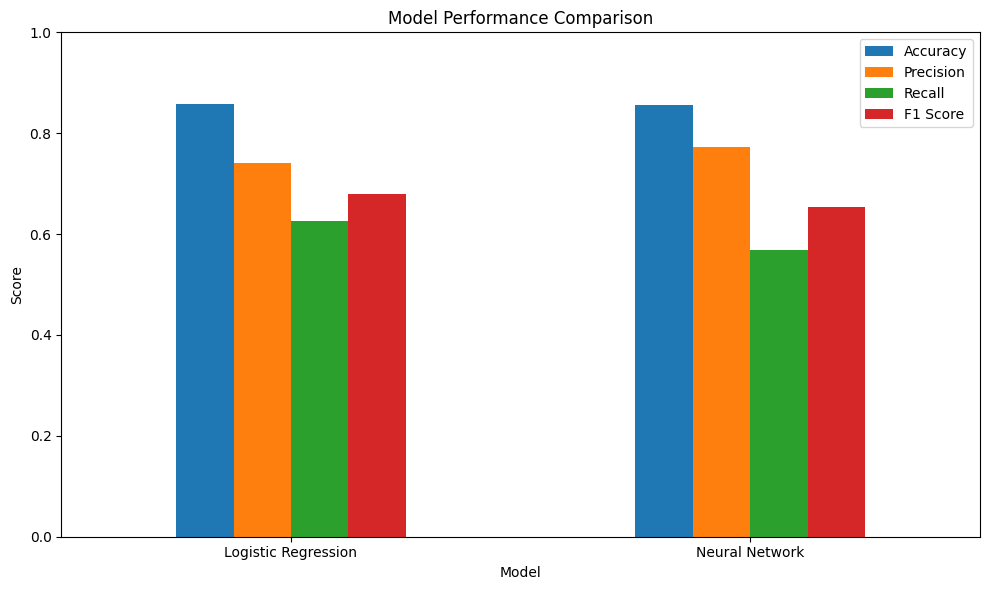

In [25]:
comparison.set_index(
    "Model"
)[
    ["Accuracy", "Precision", "Recall", "F1 Score"]
].plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0,1)

plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

In [26]:
print("=" * 50)
print("FINAL CAPSTONE PROJECT SUMMARY")
print("=" * 50)

print("\nDataset:")
print("Rows:", len(df))
print("Original columns: 15")

print("\nClustering:")
print("Algorithm: K-Means")
print("Clusters: 4")
print("Silhouette Score:",
      round(silhouette, 4))

print("\nLogistic Regression:")
print("Accuracy:",
      round(log_accuracy, 4))
print("F1 Score:",
      round(log_f1, 4))

print("\nNeural Network:")
print("Accuracy:",
      round(nn_accuracy, 4))
print("F1 Score:",
      round(nn_f1, 4))

FINAL CAPSTONE PROJECT SUMMARY

Dataset:
Rows: 32537
Original columns: 15

Clustering:
Algorithm: K-Means
Clusters: 4
Silhouette Score: 0.2589

Logistic Regression:
Accuracy: 0.8574
F1 Score: 0.6793

Neural Network:
Accuracy: 0.8556
F1 Score: 0.6544
